In [3]:
# to read .xlsx files
%pip install openpyxl

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


file_path = '/content/default of credit card clients.xls'
df = pd.read_excel(file_path, header=1, index_col=0)
display(df.head())


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## EDA

In [5]:
# Display the number of rows and columns
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# Display attributes and their data types
print("\nData types and non-null values:")
df.info()

df.describe(include="all")

Number of rows: 30000
Number of columns: 24

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
Index: 30000 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [6]:
# CHECK FOR DUPLICATE ROWS

duplicate_rows_df = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
print(f"Number of duplicate rows: {len(duplicate_rows_df)}")

if not duplicate_rows_df.empty:
  print("\nAll duplicate rows (sorted to show matches):")
  display(duplicate_rows_df.head(10))
else:
  print("No duplicate rows found.")

df.drop_duplicates(inplace=True)


print(f"DataFrame shape after dropping duplicate rows: {df.shape}")

Number of duplicate rows: 70

All duplicate rows (sorted to show matches):


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
ID,,,,,,,,,,,,,,,,,,,,,
12431,20000,1,2,2,24,2,2,4,4,4,...,1650,1650,1650,0,0,0,0,0,0,1
14295,20000,1,2,2,24,2,2,4,4,4,...,1650,1650,1650,0,0,0,0,0,0,1
1760,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
10251,50000,1,2,2,26,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
7171,50000,2,1,2,23,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
17033,50000,2,1,2,23,1,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
7367,80000,2,2,1,31,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
19115,80000,2,2,1,31,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
21769,80000,2,2,2,25,-2,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0


DataFrame shape after dropping duplicate rows: (29965, 24)


In [7]:
# Check for missing values in absolute numbers
missing_data = df.isnull().sum()
missing_cols = missing_data[missing_data > 0]

print("Absolute number of missing values per column:")
if missing_cols.empty:
    print("0 missing values detected across all columns.\n")
else:
    print(missing_cols, "\n")

Absolute number of missing values per column:
0 missing values detected across all columns.



In [8]:
# Data type conversion

categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'default payment next month']


for col in categorical_cols:
  if col in df.columns:
    df[col] = df[col].astype('category')
  else:
    print(f" Column '{col}' not found in DataFrame.")

print("\nData types after conversion:")
df.info()

print("\nFirst 5 rows after conversion:")
display(df.head())

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['category']).columns.tolist()

# Map undocumented EDUCATION values (0, 5, 6) to 4 ('others')
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)

# Map undocumented MARRIAGE values (0) to 3 ('others')
df['MARRIAGE'] = df['MARRIAGE'].replace([0], 3)

valid_values = {
'default payment next month': [0, 1],
'SEX': [1, 2],
'EDUCATION': [1, 2, 3, 4], # Including 0, 5, 6 as '4' based on common understanding/unique values
'MARRIAGE': [1, 2, 3], # Including 0 as '3' based on common understanding/unique values
'PAY_0': [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
'PAY_2': [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
'PAY_3': [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
'PAY_4': [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
'PAY_5': [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
'PAY_6': [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
}

df_clean = df.copy()


Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 29965 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   LIMIT_BAL                   29965 non-null  int64   
 1   SEX                         29965 non-null  category
 2   EDUCATION                   29965 non-null  category
 3   MARRIAGE                    29965 non-null  category
 4   AGE                         29965 non-null  int64   
 5   PAY_0                       29965 non-null  category
 6   PAY_2                       29965 non-null  category
 7   PAY_3                       29965 non-null  category
 8   PAY_4                       29965 non-null  category
 9   PAY_5                       29965 non-null  category
 10  PAY_6                       29965 non-null  category
 11  BILL_AMT1                   29965 non-null  int64   
 12  BILL_AMT2                   29965 non-null  int64

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


/tmp/ipykernel_1681/2400988038.py:22: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)
/tmp/ipykernel_1681/2400988038.py:25: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['MARRIAGE'] = df['MARRIAGE'].replace([0], 3)


In [9]:
# Check, count, and drop invalid rows for each categorical column
invalid_counts = {}
for col in categorical_cols:
  if col in valid_values:
    invalid_filter = ~df[col].isin(valid_values[col])
    invalid_rows = df[invalid_filter]
    invalid_counts[col] = invalid_rows.shape[0]
    df_clean = df_clean[~invalid_filter]
  else:
    print(f"Valid values for column '{col}' are not defined.")

# Output the results
print("\nInvalid rows for Categorical columns:")
for col, count in invalid_counts.items():
  if count > 0:
    print(f"Column '{col}': {count} invalid rows detected.")
  else:
    print(f"Column '{col}': No invalid rows detected.")

dropped_rows = df.shape[0] - df_clean.shape[0]
print(f"\nTotal rows in original DataFrame: {df.shape[0]}")
print(f"Total rows after dropping invalid entries: {df_clean.shape[0]}")
print(f"Total rows dropped: {dropped_rows}")

df = df_clean.copy()


Invalid rows for Categorical columns:
Column 'SEX': No invalid rows detected.
Column 'EDUCATION': No invalid rows detected.
Column 'MARRIAGE': No invalid rows detected.
Column 'PAY_0': No invalid rows detected.
Column 'PAY_2': No invalid rows detected.
Column 'PAY_3': No invalid rows detected.
Column 'PAY_4': No invalid rows detected.
Column 'PAY_5': No invalid rows detected.
Column 'PAY_6': No invalid rows detected.
Column 'default payment next month': No invalid rows detected.

Total rows in original DataFrame: 29965
Total rows after dropping invalid entries: 29965
Total rows dropped: 0


Advanced Domain Feature Engineering

In [10]:
# 1. Total Unpaid Balance
df['Total_Bill'] = df[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].sum(axis=1)
df['Total_Pay'] = df[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].sum(axis=1)
df['Unpaid_Balance'] = df['Total_Bill'] - df['Total_Pay']

# 2. Utilization Ratio (How much of their credit they actually use)
df['Utilization_Ratio'] = df['BILL_AMT1'] / df['LIMIT_BAL']

# 3. Late Payment Count (How many months was the payment delayed?)
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['Late_Count'] = (df[pay_cols].astype(float) > 0).sum(axis=1)

display(df[['Utilization_Ratio', 'Late_Count', 'Unpaid_Balance']].head())

,Utilization_Ratio,Late_Count,Unpaid_Balance
ID,,,
1,0.195650,2,7015
2,0.022350,2,12077
3,0.324878,0,90635
4,0.939800,0,222946
5,0.172340,0,50290


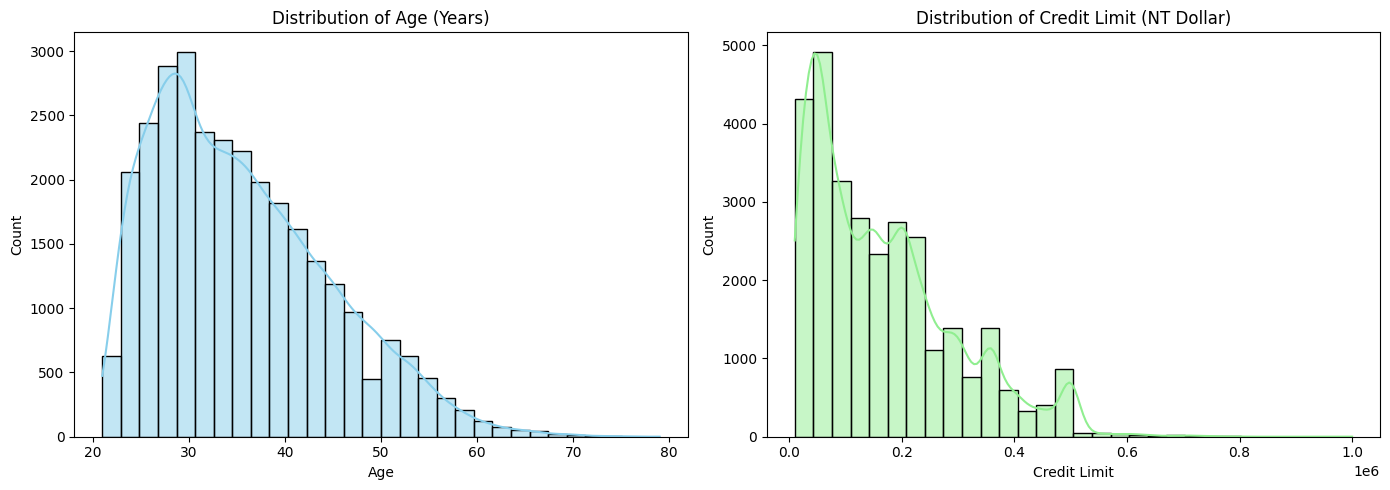


--- Summary Statistics for Monthly Bill Amounts ---


,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00
mean,51283.01,49236.37,47067.92,43313.33,40358.33,38917.01
std,73658.13,71195.57,69371.35,64353.51,60817.13,59574.15
min,-165580.00,-69777.00,-157264.00,-170000.00,-81334.00,-339603.00
25%,3595.00,3010.00,2711.00,2360.00,1787.00,1262.00
50%,22438.00,21295.00,20135.00,19081.00,18130.00,17124.00
75%,67260.00,64109.00,60201.00,54601.00,50247.00,49252.00
max,964511.00,983931.00,1664089.00,891586.00,927171.00,961664.00



--- Summary Statistics for Monthly Previous Payments ---


,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,29965.00,29965.00,29965.00,29965.00,29965.00,29965.00
mean,5670.10,5927.98,5231.69,4831.62,4804.90,5221.50
std,16571.85,23053.46,17616.36,15674.46,15286.37,17786.98
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,1000.00,850.00,390.00,300.00,261.00,131.00
50%,2102.00,2010.00,1804.00,1500.00,1500.00,1500.00
75%,5008.00,5000.00,4512.00,4016.00,4042.00,4000.00
max,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00


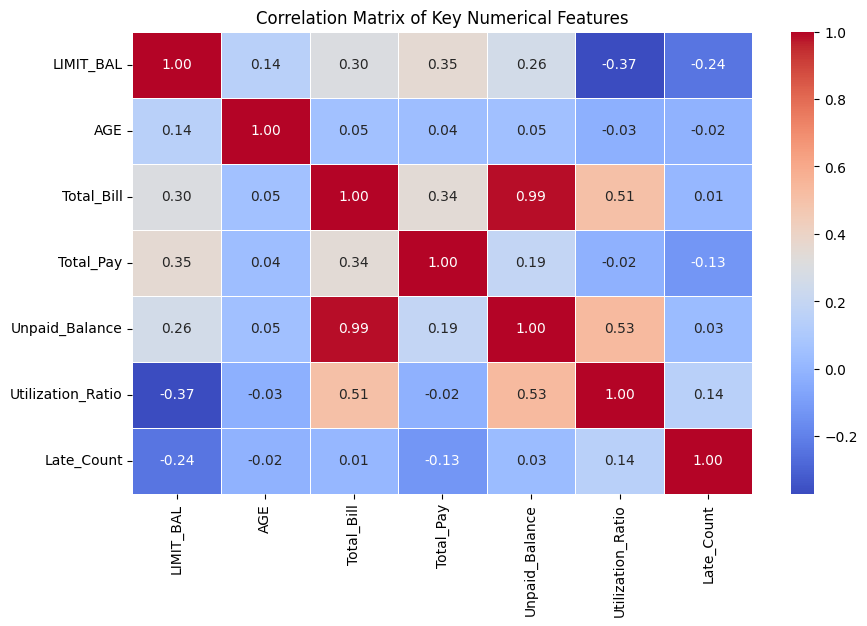

In [11]:
# 1. Distribution of AGE and LIMIT_BAL
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['AGE'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Age (Years)')
axes[0].set_xlabel('Age')

sns.histplot(df['LIMIT_BAL'], bins=30, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribution of Credit Limit (NT Dollar)')
axes[1].set_xlabel('Credit Limit')

plt.tight_layout()
plt.show()

# 2. Explore the time-series summary statistics (Sept 2005 -> April 2005)
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

print("\n--- Summary Statistics for Monthly Bill Amounts ---")
display(df[bill_cols].describe().round(2))

print("\n--- Summary Statistics for Monthly Previous Payments ---")
display(df[pay_amt_cols].describe().round(2))

# 3. Correlation Heatmap of Key Numerical Features
key_numerical_features = ['LIMIT_BAL', 'AGE', 'Total_Bill', 'Total_Pay', 'Unpaid_Balance', 'Utilization_Ratio', 'Late_Count']

plt.figure(figsize=(10, 6))
sns.heatmap(df[key_numerical_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Key Numerical Features")
plt.show()

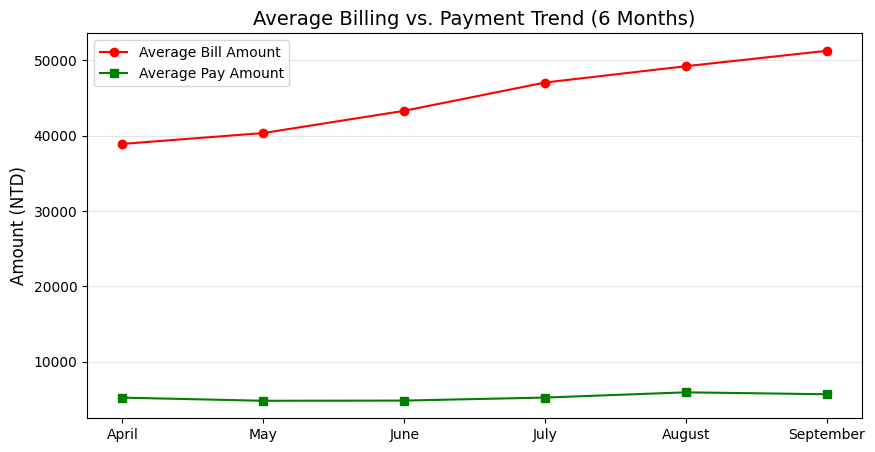

In [12]:
bill_amts = df[['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']].mean()
pay_amts = df[['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].mean()

plt.figure(figsize=(10, 5))

# Plotting the reversed arrays to display chronologically
plt.plot(range(1,7), bill_amts[::-1], marker='o', label='Average Bill Amount', color='red')
plt.plot(range(1,7), pay_amts[::-1], marker='s', label='Average Pay Amount', color='green')

plt.xticks(range(1,7), ['April', 'May', 'June', 'July', 'August', 'September'])
plt.title('Average Billing vs. Payment Trend (6 Months)', fontsize=14)
plt.ylabel('Amount (NTD)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

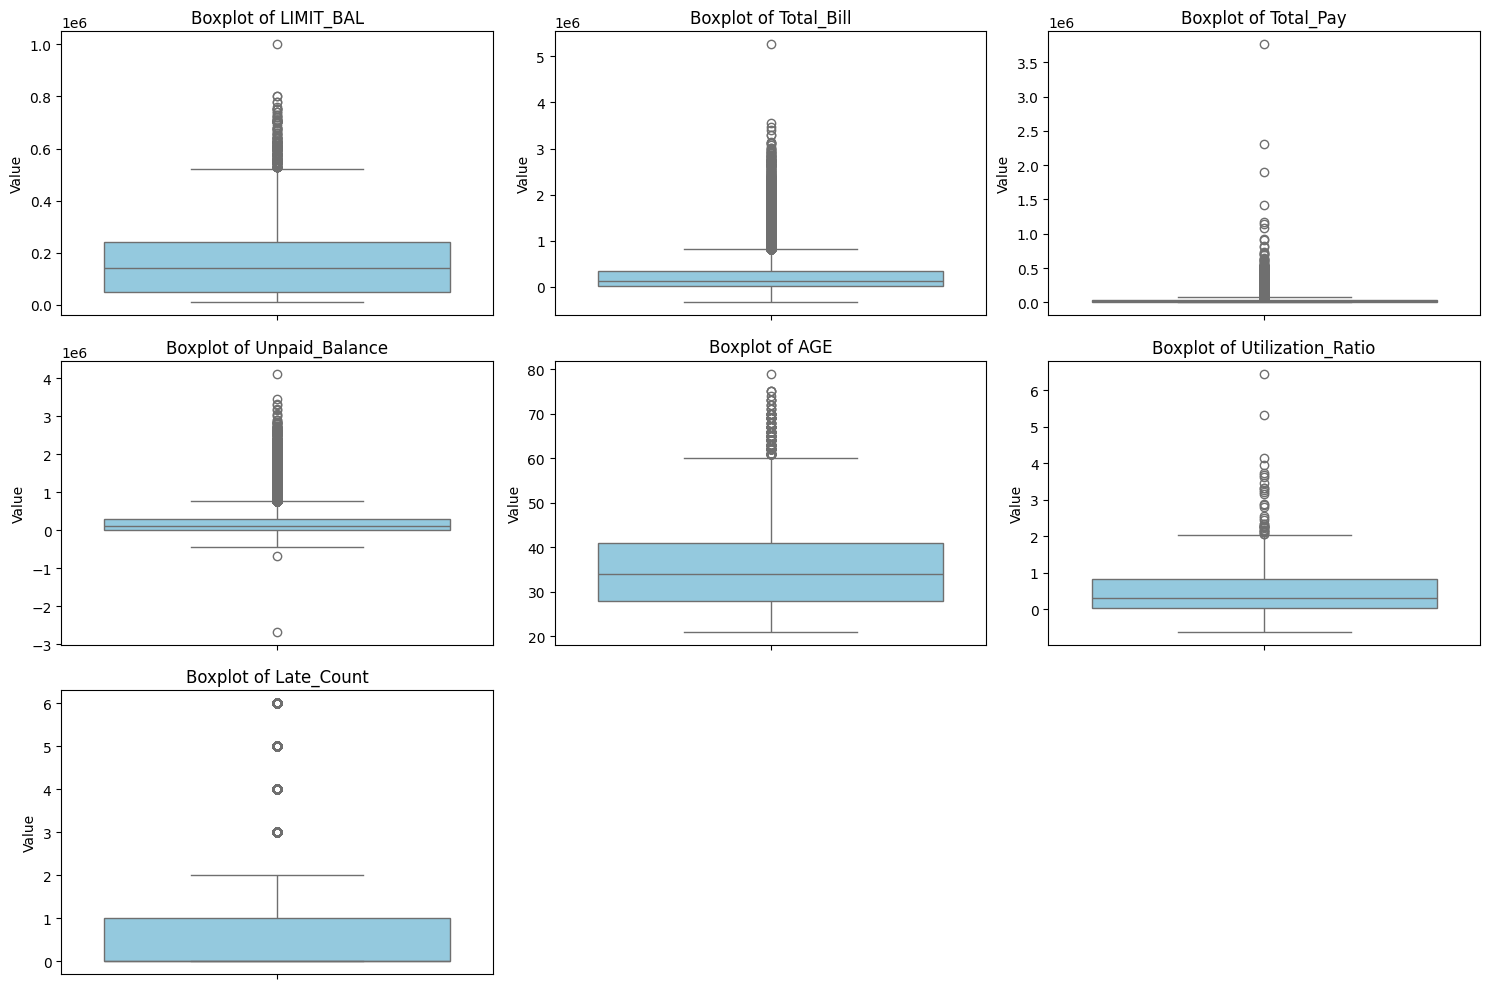

/tmp/ipykernel_1681/333698265.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default payment next month', y='LIMIT_BAL', data=df, palette='Set2')


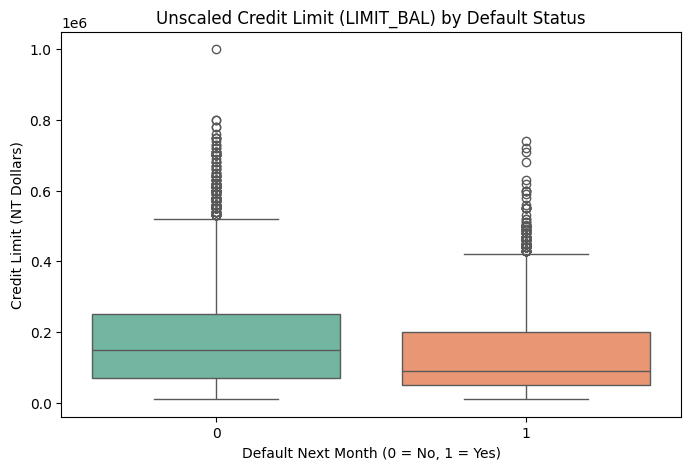

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the continuous features identified (before scaling)
features_to_plot = [
    'LIMIT_BAL', 'Total_Bill', 'Total_Pay', 'Unpaid_Balance',
    'AGE', 'Utilization_Ratio', 'Late_Count'
]

# ==========================================
# PLOT 1: Grid of Boxplots for Outlier Detection
# ==========================================
plt.figure(figsize=(15, 10))

for i, col in enumerate(features_to_plot, 1):
    plt.subplot(3, 3, i) # Creates a 3x3 grid of plots
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.ylabel('Value')

plt.tight_layout()
plt.show()

# ==========================================
# PLOT 2: Boxplot comparing a feature against Default Status
# ==========================================
plt.figure(figsize=(8, 5))
# This visualizes how the unscaled Credit Limit differs between credible and defaulting clients
sns.boxplot(x='default payment next month', y='LIMIT_BAL', data=df, palette='Set2')
plt.title('Unscaled Credit Limit (LIMIT_BAL) by Default Status')
plt.xlabel('Default Next Month (0 = No, 1 = Yes)')
plt.ylabel('Credit Limit (NT Dollars)')
plt.show()

## Normalization

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer

# 1. Define Features (X) and Target (y)
y = df['default payment next month'].astype(int)
X = df.drop(columns=['default payment next month', 'ID'], errors='ignore')

# 2. Split the dataset (80% training, 20% testing) BEFORE normalization
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Isolate ONLY the continuous and engineered features for normalization
# We intentionally exclude the one-hot encoded demographic columns (SEX, EDUCATION, MARRIAGE)
features_to_scale = [
    'LIMIT_BAL', 'Total_Bill', 'Total_Pay', 'Unpaid_Balance',
    'AGE', 'Utilization_Ratio', 'Late_Count'
]

# 4. Initialize Yeo-Johnson normalization
# (standardize=True is the default, so it scales the data simultaneously)
yeo_johnson = PowerTransformer(method='yeo-johnson')

# 5. Fit on the training data, then transform BOTH train and test sets
X_train[features_to_scale] = yeo_johnson.fit_transform(X_train[features_to_scale])
X_test[features_to_scale] = yeo_johnson.transform(X_test[features_to_scale])

print("Data successfully split and normalized!")
display(X_train[features_to_scale].head())

Data successfully split and normalized!


,LIMIT_BAL,Total_Bill,Total_Pay,Unpaid_Balance,AGE,Utilization_Ratio,Late_Count
ID,,,,,,,
27421,1.059294,-0.796211,-2.478691,-0.624496,0.134530,-1.184778,-0.702647
15351,-0.950148,0.023683,-0.400242,0.059669,0.352827,1.235632,1.722355
26642,-0.512269,-0.773788,-0.882347,-0.623103,-1.710020,-1.159344,-0.702647
21619,-0.950148,-0.771263,-0.831759,-0.622686,-1.134220,-1.149103,-0.702647
11571,0.516975,0.713197,2.440707,0.191851,-0.501622,-0.262698,-0.702647


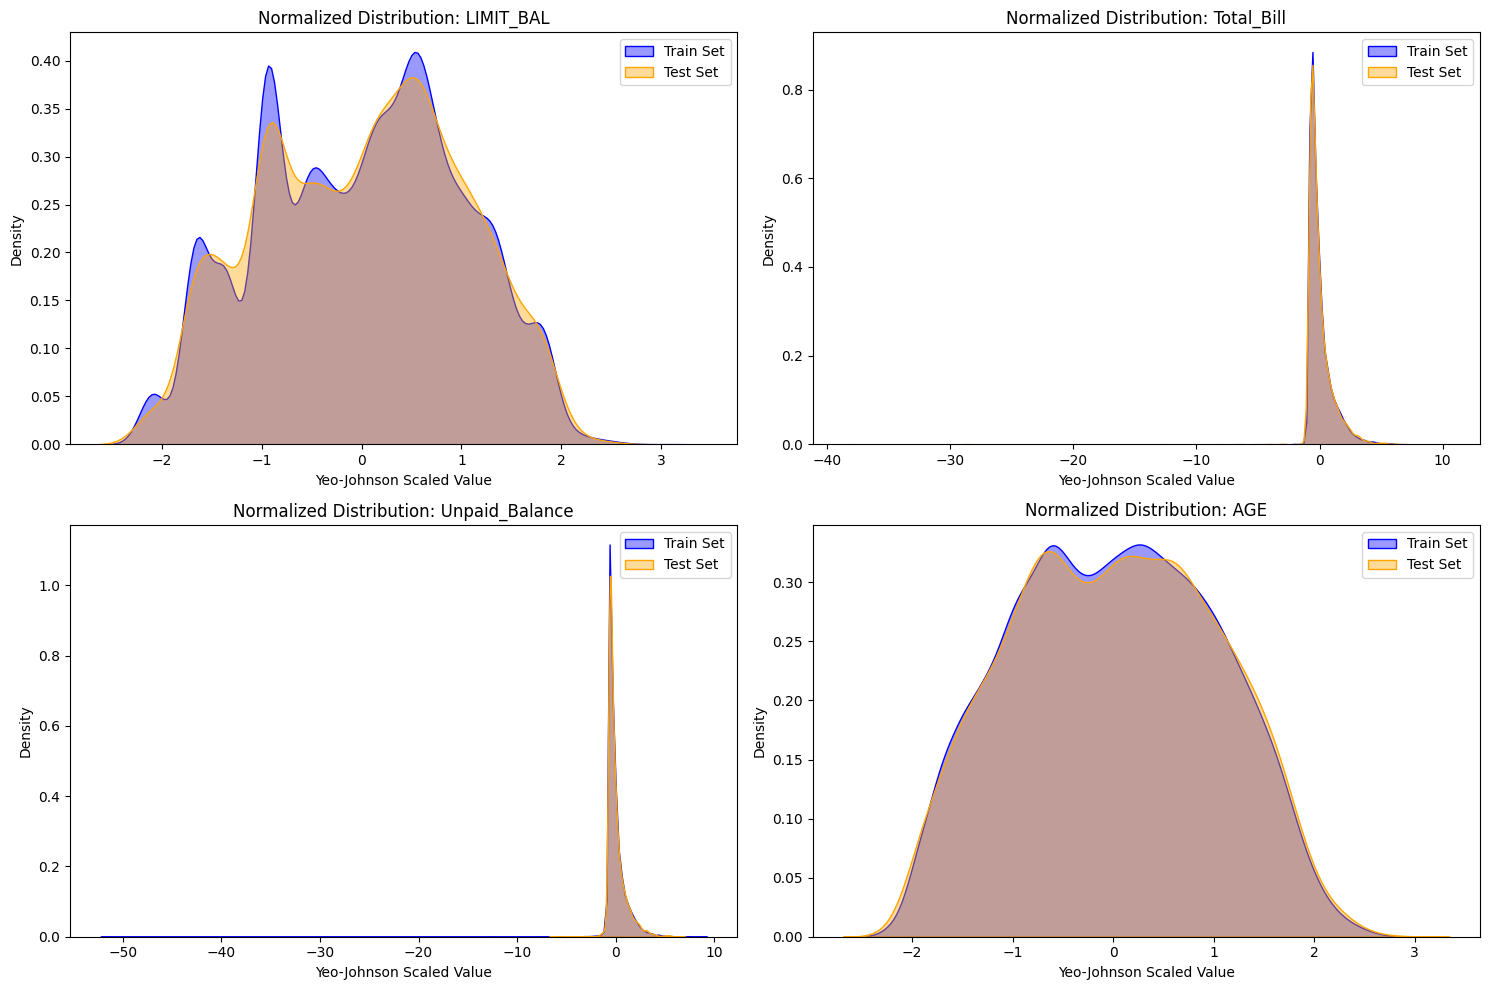

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select a few key continuous features we just normalized
features_to_check = ['LIMIT_BAL', 'Total_Bill', 'Unpaid_Balance', 'AGE']

# 2. Create an overlaid KDE (Kernel Density Estimate) plot for Train vs Test
plt.figure(figsize=(15, 10))

for i, col in enumerate(features_to_check, 1):
    plt.subplot(2, 2, i)
    # Plot the Train Set distribution in Blue
    sns.kdeplot(X_train[col], label='Train Set', fill=True, color='blue', alpha=0.4)
    # Plot the Test Set distribution in Orange
    sns.kdeplot(X_test[col], label='Test Set', fill=True, color='orange', alpha=0.4)

    plt.title(f'Normalized Distribution: {col}')
    plt.xlabel('Yeo-Johnson Scaled Value')
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()

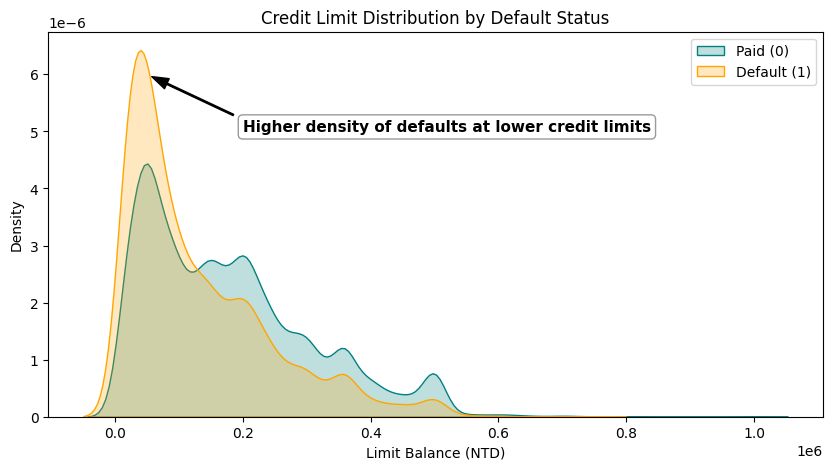

In [16]:
plt.figure(figsize=(10, 5))

sns.kdeplot(df.loc[(df['default payment next month'] == 0), 'LIMIT_BAL'], label='Paid (0)', fill=True, color='teal')
sns.kdeplot(df.loc[(df['default payment next month'] == 1), 'LIMIT_BAL'], label='Default (1)', fill=True, color='orange')

plt.title('Credit Limit Distribution by Default Status')
plt.xlabel('Limit Balance (NTD)')
plt.ylabel('Density')
plt.legend()

plt.annotate("Higher density of defaults at lower credit limits",
             xy=(50000, 0.000006),
             xytext=(200000, 0.000005),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=11,
             fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
plt.show()

--- Target Variable Counts ---
default payment next month
0    23335
1     6630
Name: count, dtype: int64

--- Default Rate Percentage ---
default payment next month
0    77.874187
1    22.125813
Name: proportion, dtype: float64


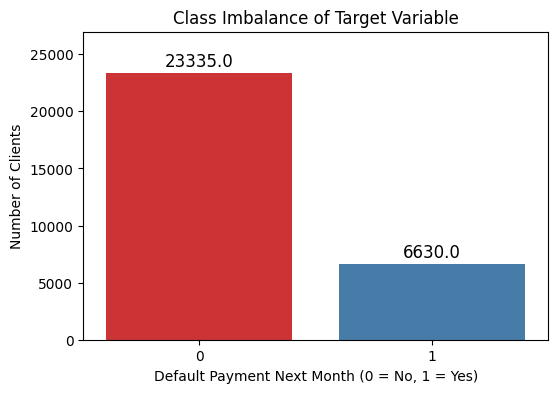

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Print the raw value counts
# ==========================================
print("--- Target Variable Counts ---")
print(df['default payment next month'].value_counts())
print("\n--- Default Rate Percentage ---")
print(df['default payment next month'].value_counts(normalize=True) * 100)

# ==========================================
# 2. Visualize the Class Imbalance
# ==========================================
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='default payment next month', data=df, hue='default payment next month', palette='Set1', legend=False)

# Add labels to the top of the bars for clarity
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Class Imbalance of Target Variable')
plt.xlabel('Default Payment Next Month (0 = No, 1 = Yes)')
plt.ylabel('Number of Clients')
plt.ylim(0, len(df) * 0.9) # Give a little headroom for the text
plt.show()


Distribution of 'default payment next month' in Training and Test Sets:


/tmp/ipykernel_1681/1409911215.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')
/tmp/ipykernel_1681/1409911215.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test, palette='viridis')


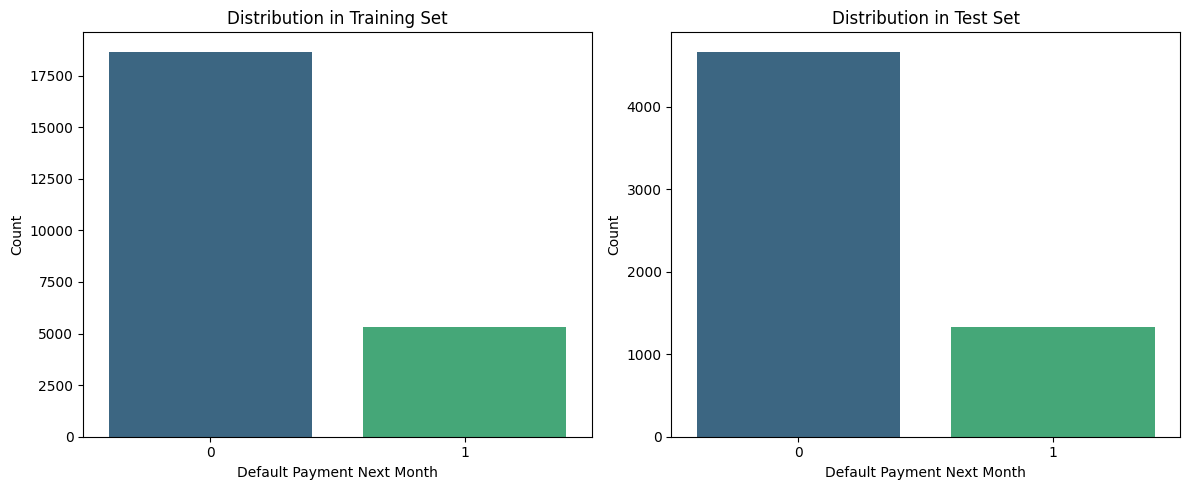

Training Set Distribution:
default payment next month
0    18668
1     5304
Name: count, dtype: int64

Test Set Distribution:
default payment next month
0    4667
1    1326
Name: count, dtype: int64


In [18]:
# Plot distribution for both testing and training set against y
print("\nDistribution of 'default payment next month' in Training and Test Sets:")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='viridis')
plt.title("Distribution in Training Set")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
sns.countplot(x=y_test, palette='viridis')
plt.title("Distribution in Test Set")
plt.xlabel("Default Payment Next Month")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

print("Training Set Distribution:")
print(pd.Series(y_train).value_counts())
print("\nTest Set Distribution:")
print(pd.Series(y_test).value_counts())

## Feature Selection

In [19]:
!pip install boruta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.2 MB/s eta 0:00:00


In [20]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy

# ==========================================
# 1. Setup the Base Model for Boruta
# ==========================================
# Boruta requires a Random Forest base estimator to calculate importances.
# We use max_depth=5 to keep the trees simple and prevent overfitting during selection.
rf_base = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)

# ==========================================
# 2. Initialize the Boruta Wrapper
# ==========================================
# n_estimators='auto' lets Boruta automatically choose the right number of trees
boruta_selector = BorutaPy(rf_base, n_estimators='auto', verbose=2, random_state=42)

# ==========================================
# 3. Run the Shadow Feature Selection
# ==========================================
print("Running Boruta Feature Selection... (This generates and tests shadow features)")
# Boruta requires numpy arrays rather than Pandas DataFrames, so we use .values
boruta_selector.fit(X_train.values, y_train.values)

# ==========================================


Running Boruta Feature Selection... (This generates and tests shadow features)
Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	28
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	28
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	28
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	28
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	28
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	28
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	28
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	24
Tentative: 	1
Rejected: 	3
Iteration: 	9 / 100
Confirmed: 	24
Tentative: 	1
Rejected: 	3
Iteration: 	10 / 100
Confirmed: 	24
Tentative: 	1
Rejected: 	3
Iteration: 	11 / 100
Confirmed: 	24
Tentative: 	1
Rejected: 	3
Iteration: 	12 / 100
Confirmed: 	24
Tentative: 	1
Rejected: 	3
Iteration: 	13 / 100
Confirmed: 	24
Tentative: 	1
Rejected: 	3
Iteration: 	14 / 100
Confirmed: 	24
Tentative: 	1
Rejected: 	3
Iteration: 	15 / 100
Confirmed: 	24
Tentative: 	

BorutaPy(estimator=RandomForestClassifier(class_weight='balanced', max_depth=5,
                                          n_estimators=141, n_jobs=-1,
                                          random_state=RandomState(MT19937) at 0x7C88F52DBA40),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7C88F52DBA40, verbose=2)

In [21]:
# 4. Extract and Apply Results
# ==========================================
# boruta_selector.support_ returns a boolean array (True for keep, False for drop)
selected_features = X_train.columns[boruta_selector.support_].to_list()
rejected_features = X_train.columns[~boruta_selector.support_].to_list()

print("\n--- Boruta Feature Selection Results ---")
print(f"Original number of features: {X_train.shape[1]}")
print(f"Selected (Confirmed) features: {len(selected_features)}")
print(f"Rejected features (Worse than randomness): {len(rejected_features)}")

print("\n✅ Confirmed Features to KEEP:")
print(selected_features)

print("\n❌ Rejected Features to DROP:")
print(rejected_features)

# ==========================================
# 5. Create the Final Optimized Datasets
# ==========================================
X_train_optimized = X_train[selected_features]
X_test_optimized = X_test[selected_features]

# update our SMOTENC categorical indices
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']
new_cat_indices = [X_train_optimized.columns.get_loc(col) for col in categorical_features if col in X_train_optimized.columns]


--- Boruta Feature Selection Results ---
Original number of features: 28
Selected (Confirmed) features: 24
Rejected features (Worse than randomness): 4

✅ Confirmed Features to KEEP:
['LIMIT_BAL', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Total_Bill', 'Total_Pay', 'Unpaid_Balance', 'Utilization_Ratio', 'Late_Count']

❌ Rejected Features to DROP:
['SEX', 'EDUCATION', 'MARRIAGE', 'AGE']


## RANDOM FOREST (SMOTE vs class-weighted)

In [22]:
import pandas as pd
import numpy as np
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterSampler, cross_validate
from sklearn.base import clone
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, accuracy_score
from tqdm import tqdm
# =========================================================
# 1. Setup the Scoring Metrics
# =========================================================
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

# =========================================================
# 2. Define the Two Competing Approaches
# =========================================================

# Approach A: The SMOTE Pipeline (Synthesizes Data)
smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

# Approach B: The Class Weight Pipeline (No SMOTE, penalizes errors)
# We use a standard Sklearn Pipeline since we aren't resampling
weight_pipeline = SkPipeline([
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42))
])

# =========================================================
# 3. Define the Hyperparameter Grids to find "Optimal Class 1"
# =========================================================

# For SMOTE, we can test the sampling strategy (e.g., 80% balance vs 100% balance)
smote_grid = {
    'smote__sampling_strategy': [0.8, 1.0]
}

# For Class Weights, we test different penalties for Class 1 (Defaulters)
# {0: 1, 1: 3} means: "If you miss a defaulter, it hurts 3 times as much as missing a payer"
weight_grid = {
    'rf__class_weight': [
        'balanced',          # Sklearn's default auto-balancer
        {0: 1, 1: 2},        # Class 1 is 2x more important
        {0: 1, 1: 3},        # Class 1 is 3x more important
        {0: 1, 1: 5},        # Class 1 is 5x more important
        {0: 1, 1: 10}        # Class 1 is 10x more important
    ]
}

# =========================================================
# 4. Custom Search Loop to Compare Both
# =========================================================
results_list = []

print("Starting Duel: SMOTE vs. Optimal Class Weights...")

# --- Evaluate SMOTE Approach ---
print("\nTesting SMOTE Parameters...")
for params in ParameterSampler(smote_grid, n_iter=2, random_state=42):
    current_pipe = clone(smote_pipeline)
    current_pipe.set_params(**params)

    cv_results = cross_validate(current_pipe, X_train_optimized, y_train, cv=5, scoring=scoring, n_jobs=-1)

    results_list.append({
        "Method": f"SMOTE (Ratio: {params['smote__sampling_strategy']})",
        "Accuracy": np.mean(cv_results['test_accuracy']),
        "Precision": np.mean(cv_results['test_precision']),
        "Recall": np.mean(cv_results['test_recall']),
        "F1-Score": np.mean(cv_results['test_f1'])
    })

# --- Evaluate Class Weight Approach ---
print("Testing Optimal Class 1 Weights...")
for params in ParameterSampler(weight_grid, n_iter=5, random_state=42):
    current_pipe = clone(weight_pipeline)
    current_pipe.set_params(**params)

    cv_results = cross_validate(current_pipe, X_train_optimized, y_train, cv=5, scoring=scoring, n_jobs=-1)

    # Format the weight name for the leaderboard
    weight_name = params['rf__class_weight']
    if isinstance(weight_name, dict):
        weight_name = f"Weight (Class 1 = {weight_name[1]}x)"
    else:
        weight_name = "Weight (Auto-Balanced)"

    results_list.append({
        "Method": weight_name,
        "Accuracy": np.mean(cv_results['test_accuracy']),
        "Precision": np.mean(cv_results['test_precision']),
        "Recall": np.mean(cv_results['test_recall']),
        "F1-Score": np.mean(cv_results['test_f1'])
    })

# =========================================================
# 5. Display the Final Showdown Leaderboard
# =========================================================
comparison_df = pd.DataFrame(results_list).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print("\n--- Final Leaderboard: SMOTE vs Optimal Class Weights ---")
display(comparison_df)

Starting Duel: SMOTE vs. Optimal Class Weights...

Testing SMOTE Parameters...
Testing Optimal Class 1 Weights...

--- Final Leaderboard: SMOTE vs Optimal Class Weights ---


,Method,Accuracy,Precision,Recall,F1-Score
0,Weight (Class 1 = 3x),0.797055,0.541483,0.542984,0.542083
1,Weight (Auto-Balanced),0.785166,0.513311,0.566173,0.538340
2,Weight (Class 1 = 2x),0.811822,0.590497,0.488308,0.534487
3,Weight (Class 1 = 5x),0.746997,0.449361,0.636307,0.526674
4,SMOTE (Ratio: 1.0),0.812948,0.609246,0.431184,0.504906
5,SMOTE (Ratio: 0.8),0.815535,0.621778,0.424584,0.504565
6,Weight (Class 1 = 10x),0.573753,0.321053,0.830692,0.463095


Starting Duel to find Real Optimal Parameters...

Applying Real SMOTE Parameters: {'smote__sampling_strategy': 1.0}
Applying Real Class-Weight Parameters: {'rf__class_weight': {0: 1, 1: 3}}

Training final champions with actual results...


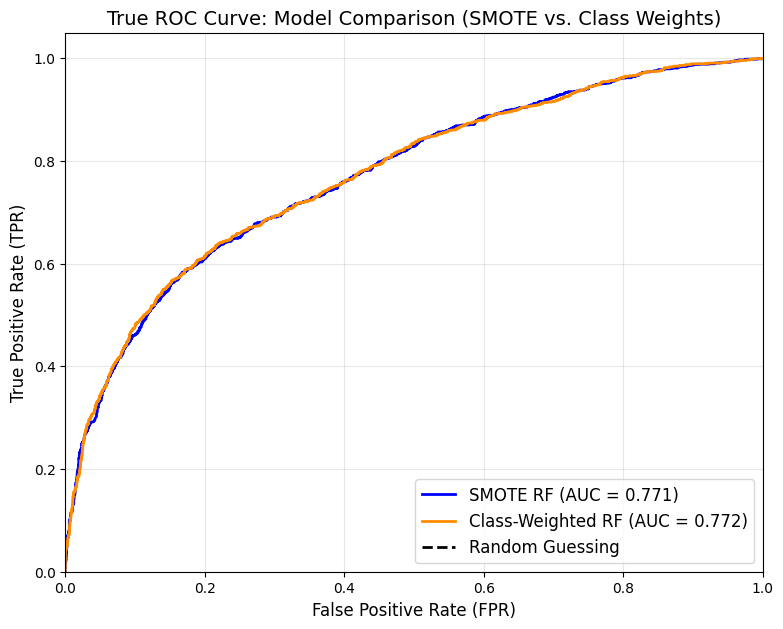

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np
import pandas as pd
from sklearn.base import clone

# =========================================================
# 1. Variables to capture the REAL Optimal Results
# =========================================================
best_smote_f1 = 0
best_smote_params = None

best_weight_f1 = 0
best_weight_params = None

print("Starting Duel to find Real Optimal Parameters...")

# --- Evaluate SMOTE Approach ---
for params in ParameterSampler(smote_grid, n_iter=2, random_state=42):
    current_pipe = clone(smote_pipeline)
    current_pipe.set_params(**params)

    cv_results = cross_validate(current_pipe, X_train_optimized, y_train, cv=5, scoring=scoring, n_jobs=-1)
    mean_f1 = np.mean(cv_results['test_f1'])

    # Dynamically assign the real best result
    if mean_f1 > best_smote_f1:
        best_smote_f1 = mean_f1
        best_smote_params = params

# --- Evaluate Class Weight Approach ---
for params in ParameterSampler(weight_grid, n_iter=5, random_state=42):
    current_pipe = clone(weight_pipeline)
    current_pipe.set_params(**params)

    cv_results = cross_validate(current_pipe, X_train_optimized, y_train, cv=5, scoring=scoring, n_jobs=-1)
    mean_f1 = np.mean(cv_results['test_f1'])

    # Dynamically assign the real best result
    if mean_f1 > best_weight_f1:
        best_weight_f1 = mean_f1
        best_weight_params = params

# =========================================================
# 2. Assign the REAL Variables to the Champions
# =========================================================
print(f"\nApplying Real SMOTE Parameters: {best_smote_params}")
print(f"Applying Real Class-Weight Parameters: {best_weight_params}")

# Clone fresh pipelines and inject the real optimal variables!
champ_smote = clone(smote_pipeline)
champ_smote.set_params(**best_smote_params)

champ_weight = clone(weight_pipeline)
champ_weight.set_params(**best_weight_params)

# Train the true champions on the full training data
print("\nTraining final champions with actual results...")
champ_smote.fit(X_train_optimized, y_train)
champ_weight.fit(X_train_optimized, y_train)

# =========================================================
# 3. Predict Probabilities & Plot True ROC Curve
# =========================================================
# Get continuous probability scores needed for the ROC Curve
y_prob_smote = champ_smote.predict_proba(X_test_optimized)[:, 1]
y_prob_weight = champ_weight.predict_proba(X_test_optimized)[:, 1]

fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)
auc_smote = auc(fpr_smote, tpr_smote)

fpr_weight, tpr_weight, _ = roc_curve(y_test, y_prob_weight)
auc_weight = auc(fpr_weight, tpr_weight)

# Plotting the visualization
plt.figure(figsize=(9, 7))

plt.plot(fpr_smote, tpr_smote, color='blue', lw=2, label=f'SMOTE RF (AUC = {auc_smote:.3f})')
plt.plot(fpr_weight, tpr_weight, color='darkorange', lw=2, label=f'Class-Weighted RF (AUC = {auc_weight:.3f})')

plt.plot([1], color='black', lw=2, linestyle='--', label='Random Guessing')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('True ROC Curve: Model Comparison (SMOTE vs. Class Weights)', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

## ANN

In [24]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline as SkPipeline # Import standard Pipeline for sub-steps
from imblearn.over_sampling import SMOTENC # Use SMOTENC for categorical features
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import ParameterSampler, cross_validate
from sklearn.base import clone
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, accuracy_score
from sklearn.compose import ColumnTransformer # Import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer

# =========================================================
# 1. Setup the ANN Pipeline with SMOTE
# =========================================================

# Assuming X_train_optimized is available from previous cells.
# Identify numerical and categorical columns within the optimized feature set.
# Note: 'PAY_0' through 'PAY_6' are treated as categorical here as they were originally.
numerical_cols_optimized = X_train_optimized.select_dtypes(include=np.number).columns.tolist()
categorical_cols_optimized = X_train_optimized.select_dtypes(include='category').columns.tolist()

# Define preprocessing steps for numerical features. These are the same as before.
numerical_transformer = SkPipeline(steps=[
    ('imputer_inf', SimpleImputer(missing_values=np.inf, strategy='constant', fill_value=np.nan)),
    ('imputer_neg_inf', SimpleImputer(missing_values=-np.inf, strategy='constant', fill_value=np.nan)),
    ('imputer_nan', SimpleImputer(strategy='constant', fill_value=0)),
    ('power_transformer', PowerTransformer(method='yeo-johnson'))
])

# Create a ColumnTransformer for the optimized features.
# Numerical features are transformed, categorical features are passed through to SMOTENC.
preprocessor_optimized = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols_optimized),
        ('cat', 'passthrough', categorical_cols_optimized) # Pass categorical as-is for SMOTENC
    ],
    remainder='drop' # Drop any other columns not explicitly listed
)

# Define the categorical indices for SMOTENC based on the output order of the preprocessor.
smotenc_categorical_indices_optimized = list(range(
    len(numerical_cols_optimized),
    len(numerical_cols_optimized) + len(categorical_cols_optimized)
))

# Setup the ANN Pipeline with the new preprocessor and SMOTENC.
ann_pipeline = ImbPipeline([
    ('preprocessor', preprocessor_optimized), # Apply preprocessing to optimized features
    ('smotenc', SMOTENC(categorical_features=smotenc_categorical_indices_optimized, random_state=42)), # Then, apply SMOTENC
    ('ann', MLPClassifier(max_iter=1000, early_stopping=True, random_state=42))
])

scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

# =========================================================
# 2. The Deep Learning Hyperparameter Grid
# =========================================================
# Testing everything from shallow networks to very deep hierarchical networks
param_grid_ann = {
    'ann__hidden_layer_sizes': [(50,), (100, 50), (200, 100), (100, 100, 50)],
    'ann__learning_rate_init': [0.0005, 0.001, 0.01, 0.05],
    'ann__alpha': [0.0001, 0.001, 0.01], # L2 regularization to prevent overfitting
    'ann__activation': ['relu', 'tanh']
}

# Generate 20 random combinations to keep training time manageable
param_list_ann = list(ParameterSampler(param_grid_ann, n_iter=20, random_state=42))

best_ann_f1 = 0
best_ann_params = None
best_ann_cv_results = None

print("Starting Deep Learning Architecture Search on Optimized Data...")

# =========================================================
# 3. Custom Search Loop
# =========================================================
for params in tqdm(param_list_ann, desc="Evaluating ANNs"):

    current_pipe = clone(ann_pipeline)
    current_pipe.set_params(**params)

    # CRUCIAL: We train ONLY on X_train_optimized (the Boruta purified data!)
    cv_results = cross_validate(
        current_pipe, X_train_optimized, y_train,
        cv=5, scoring=scoring, n_jobs=-1
    )

    mean_f1 = np.mean(cv_results['test_f1'])

    if mean_f1 > best_ann_f1:
        best_ann_f1 = mean_f1
        best_ann_params = params
        best_ann_cv_results = cv_results

# =========================================================
# 4. Display Final ANN Champion
# =========================================================
print("\n=== CHAMPION NEURAL NETWORK ARCHITECTURE ===")
for param_name, param_value in best_ann_params.items():
    clean_name = param_name.replace("ann__", "")
    print(f"{clean_name}: {param_value}")

print("\n=== Cross-Validated Metrics ===")
print(f"Mean Accuracy:  {np.mean(best_ann_cv_results['test_accuracy']):.4f}")
print(f"Mean Precision: {np.mean(best_ann_cv_results['test_precision']):.4f}")
print(f"Mean Recall:    {np.mean(best_ann_cv_results['test_recall']):.4f}")
print(f"Mean F1 Score:  {np.mean(best_ann_cv_results['test_f1']):.4f}")

Starting Deep Learning Architecture Search on Optimized Data...


Evaluating ANNs: 100%|██████████| 20/20 [43:39<00:00, 130.95s/it]


=== CHAMPION NEURAL NETWORK ARCHITECTURE ===
learning_rate_init: 0.0005
hidden_layer_sizes: (50,)
alpha: 0.01
activation: tanh

=== Cross-Validated Metrics ===
Mean Accuracy:  0.7514
Mean Precision: 0.4560
Mean Recall:    0.6291
Mean F1 Score:  0.5284


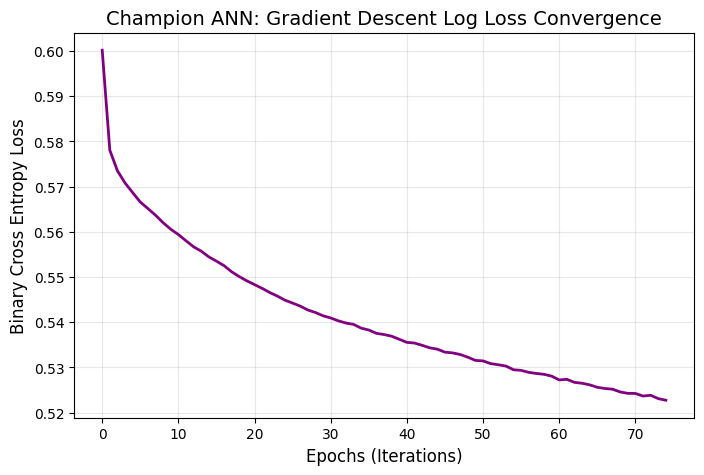

Evaluating Champion ANN on the unseen Holdout Test Set...


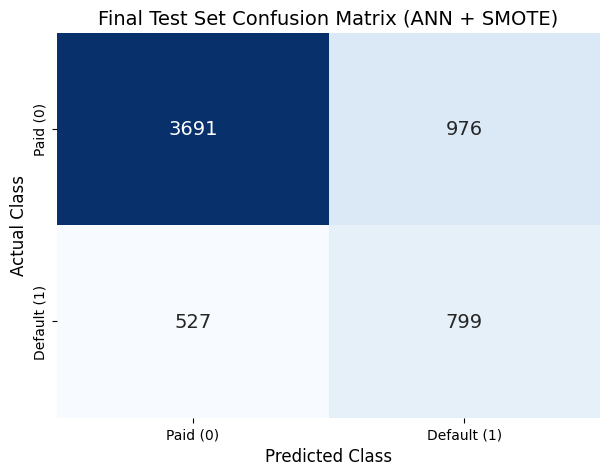

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import pandas as pd # Needed for X_train_optimized.select_dtypes
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.over_sampling import SMOTENC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import ParameterSampler, cross_validate
from sklearn.base import clone
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score, accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer

# Re-defining components necessary to correctly regenerate best_ann_cv_results
# This section essentially repeats parts of HLcUdTTW8K7U to make this cell self-contained and fix the error.

# 1. Setup the ANN Pipeline with SMOTE
# Assuming X_train_optimized is available from previous cells (it is in kernel state).
# Identify numerical and categorical columns within the optimized feature set.
numerical_cols_optimized = X_train_optimized.select_dtypes(include=np.number).columns.tolist()
categorical_cols_optimized = X_train_optimized.select_dtypes(include='category').columns.tolist()

# Define preprocessing steps for numerical features.
numerical_transformer = SkPipeline(steps=[
    ('imputer_inf', SimpleImputer(missing_values=np.inf, strategy='constant', fill_value=np.nan)),
    ('imputer_neg_inf', SimpleImputer(missing_values=-np.inf, strategy='constant', fill_value=np.nan)),
    ('imputer_nan', SimpleImputer(strategy='constant', fill_value=0)),
    ('power_transformer', PowerTransformer(method='yeo-johnson'))
])

# Create a ColumnTransformer for the optimized features.
preprocessor_optimized = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols_optimized),
        ('cat', 'passthrough', categorical_cols_optimized)
    ],
    remainder='drop'
)

# Define the categorical indices for SMOTENC based on the output order of the preprocessor.
smotenc_categorical_indices_optimized = list(range(
    len(numerical_cols_optimized),
    len(numerical_cols_optimized) + len(categorical_cols_optimized)
))

# Setup the ANN Pipeline with the new preprocessor and SMOTENC.
ann_pipeline = ImbPipeline([
    ('preprocessor', preprocessor_optimized),
    ('smotenc', SMOTENC(categorical_features=smotenc_categorical_indices_optimized, random_state=42)),
    ('ann', MLPClassifier(max_iter=1000, early_stopping=True, random_state=42))
])

# Setup scoring metrics (needed for cross_validate)
scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}

# RE-RUN cross_validate for the best ANN parameters WITH return_estimator=True
# Use best_ann_params from the kernel state. This variable is available.
current_pipe = clone(ann_pipeline)
current_pipe.set_params(**best_ann_params)

# CRUCIAL CHANGE: Add return_estimator=True
best_ann_cv_results = cross_validate(
    current_pipe, X_train_optimized, y_train,
    cv=5, scoring=scoring, n_jobs=-1, return_estimator=True # <--- THE FIX
)

# End of re-calculation part
# =========================================================

# 1. Extract the Champion ANN from the cross-validation results
# best_ann_cv_results contains the fitted estimators from the 5 folds.
# We will extract the best performing fold's pipeline.
best_fold_index = np.argmax(best_ann_cv_results['test_f1'])
champion_pipeline = best_ann_cv_results['estimator'][best_fold_index]

# Extract just the ANN model from the pipeline
champion_ann = champion_pipeline.named_steps['ann']

# =========================================================
# 2. Plot the Gradient Descent Loss Curve
# =========================================================
plt.figure(figsize=(8, 5))
# The loss_curve_ attribute stores the error at each iteration
plt.plot(champion_ann.loss_curve_, color='purple', linewidth=2)
plt.title('Champion ANN: Gradient Descent Log Loss Convergence', fontsize=14)
plt.xlabel('Epochs (Iterations)', fontsize=12)
plt.ylabel('Binary Cross Entropy Loss', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

# =========================================================
# 3. Final Evaluation on the UNSEEN Test Set
# =========================================================
print("Evaluating Champion ANN on the unseen Holdout Test Set...")

# Generate final predictions using the fully optimized test data
y_pred_final = champion_pipeline.predict(X_test_optimized)

# Create the final Confusion Matrix
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Paid (0)', 'Default (1)'],
            yticklabels=['Paid (0)', 'Default (1)'],
            annot_kws={"size": 14})
plt.title('Final Test Set Confusion Matrix (ANN + SMOTE)', fontsize=14)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('Actual Class', fontsize=12)
plt.show()

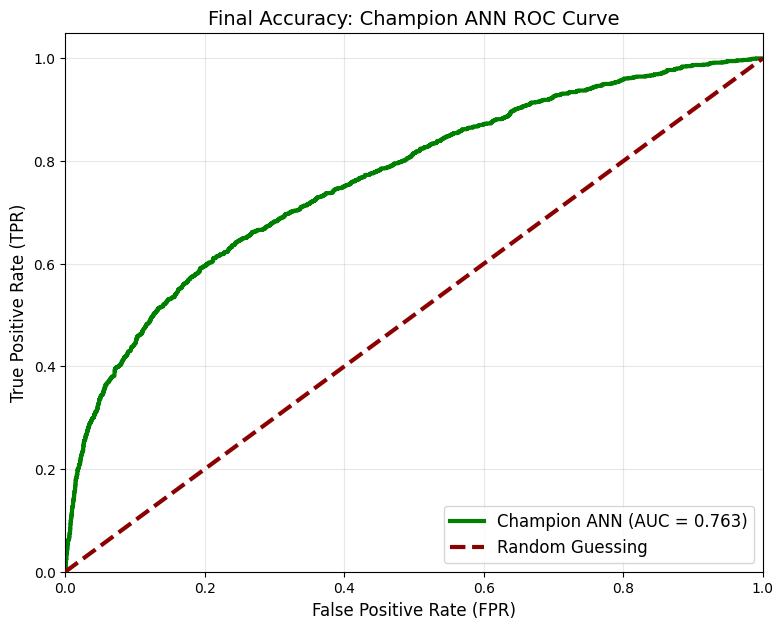

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# =========================================================
# 1. Get Predicted Probabilities from the Champion ANN
# =========================================================
# We use predict_proba to get the continuous probability scores on the UNSEEN test set
y_prob_ann = champion_pipeline.predict_proba(X_test_optimized)[:, 1]

# =========================================================
# 2. Calculate ROC Metrics
# =========================================================
# Calculate False Positive Rate (FPR) and True Positive Rate (TPR)
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_prob_ann)

# Calculate the Area Under the Curve (AUC) - This is your final accuracy measure!
auc_ann = auc(fpr_ann, tpr_ann)

# =========================================================
# 3. Plot the Final ROC "Accuracy" Curve
# =========================================================
plt.figure(figsize=(9, 7))

# Plot the Champion ANN's curve
plt.plot(fpr_ann, tpr_ann, color='green', lw=3, label=f'Champion ANN (AUC = {auc_ann:.3f})')

# Plot the "Random Guessing" diagonal line representing 0.5 accuracy
plt.plot([0, 1], [0, 1], color='darkred', lw=3, linestyle='--', label='Random Guessing', zorder=5) # Corrected random guessing line and made more prominent

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Final Accuracy: Champion ANN ROC Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Training ANNs to compare activation convergence...
Training with relu...
Training with tanh...
Training with logistic...


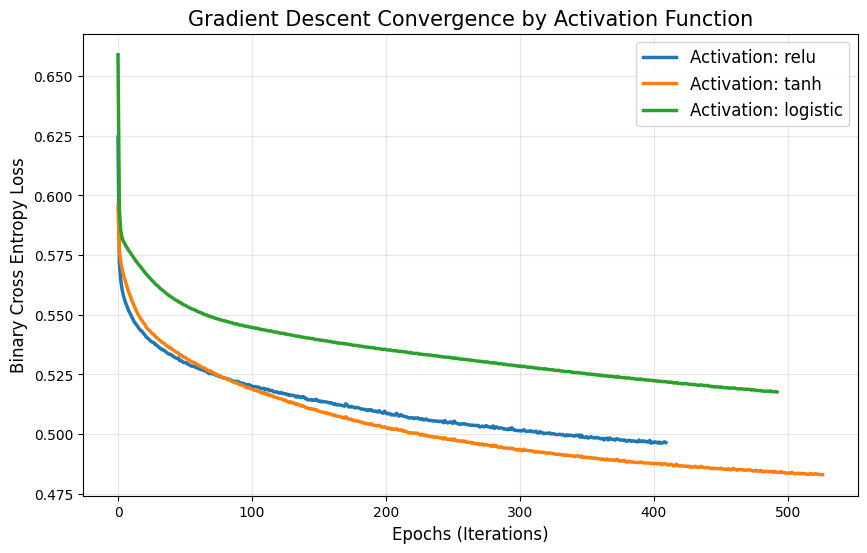

In [27]:
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTENC # Changed from SMOTE to SMOTENC
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline as SkPipeline # Import standard Pipeline for sub-steps

# 1. Define the activation functions from your lecture notes to compare
# 'logistic' is the scikit-learn equivalent for the Sigmoid function
activations = ['relu', 'tanh', 'logistic']

# --- Re-define preprocessing components from HLcUdTTW8K7U for consistent data handling ---
# Identify numerical and categorical columns within the optimized feature set.
# Note: 'PAY_0' through 'PAY_6' are treated as categorical here as they were originally.
numerical_cols_optimized = X_train_optimized.select_dtypes(include=np.number).columns.tolist()
categorical_cols_optimized = X_train_optimized.select_dtypes(include='category').columns.tolist()

# Define preprocessing steps for numerical features.
numerical_transformer = SkPipeline(steps=[
    ('imputer_inf', SimpleImputer(missing_values=np.inf, strategy='constant', fill_value=np.nan)),
    ('imputer_neg_inf', SimpleImputer(missing_values=-np.inf, strategy='constant', fill_value=np.nan)),
    ('imputer_nan', SimpleImputer(strategy='constant', fill_value=0)),
    ('power_transformer', PowerTransformer(method='yeo-johnson'))
])

# Create a ColumnTransformer for the optimized features.
preprocessor_optimized = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols_optimized),
        ('cat', 'passthrough', categorical_cols_optimized) # Pass categorical as-is for SMOTENC
    ],
    remainder='drop'
)

# Define the categorical indices for SMOTENC based on the output order of the preprocessor.
smotenc_categorical_indices_optimized = list(range(
    len(numerical_cols_optimized),
    len(numerical_cols_optimized) + len(categorical_cols_optimized)
))
# --- End of preprocessing component definitions ---

print("Training ANNs to compare activation convergence...")

plt.figure(figsize=(10, 6))

# 2. Preprocess the training data first
X_train_processed = preprocessor_optimized.fit_transform(X_train_optimized)

# 3. Then balance the training data using SMOTENC
smotenc = SMOTENC(categorical_features=smotenc_categorical_indices_optimized, sampling_strategy=1.0, random_state=42)
X_train_smote, y_train_smote = smotenc.fit_resample(X_train_processed, y_train)

# 4. Loop through each activation function and train a model
for act in activations:
    print(f"Training with {act}...")

    ann = MLPClassifier(
        hidden_layer_sizes=(50,),
        learning_rate_init=0.0005,
        alpha=0.01,
        activation=act,
        max_iter=1000,
        random_state=42
    )

    # Fit the neural network
    ann.fit(X_train_smote, y_train_smote)

    # Plot the loss curve for this specific activation function
    plt.plot(ann.loss_curve_, label=f"Activation: {act}", linewidth=2.5)

# 5. Format the final comparative graph
plt.title('Gradient Descent Convergence by Activation Function', fontsize=15)
plt.xlabel('Epochs (Iterations)', fontsize=12)
plt.ylabel('Binary Cross Entropy Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Training ANNs to compare Loss and Accuracy...
Training with relu...
Training with tanh...
Training with logistic...


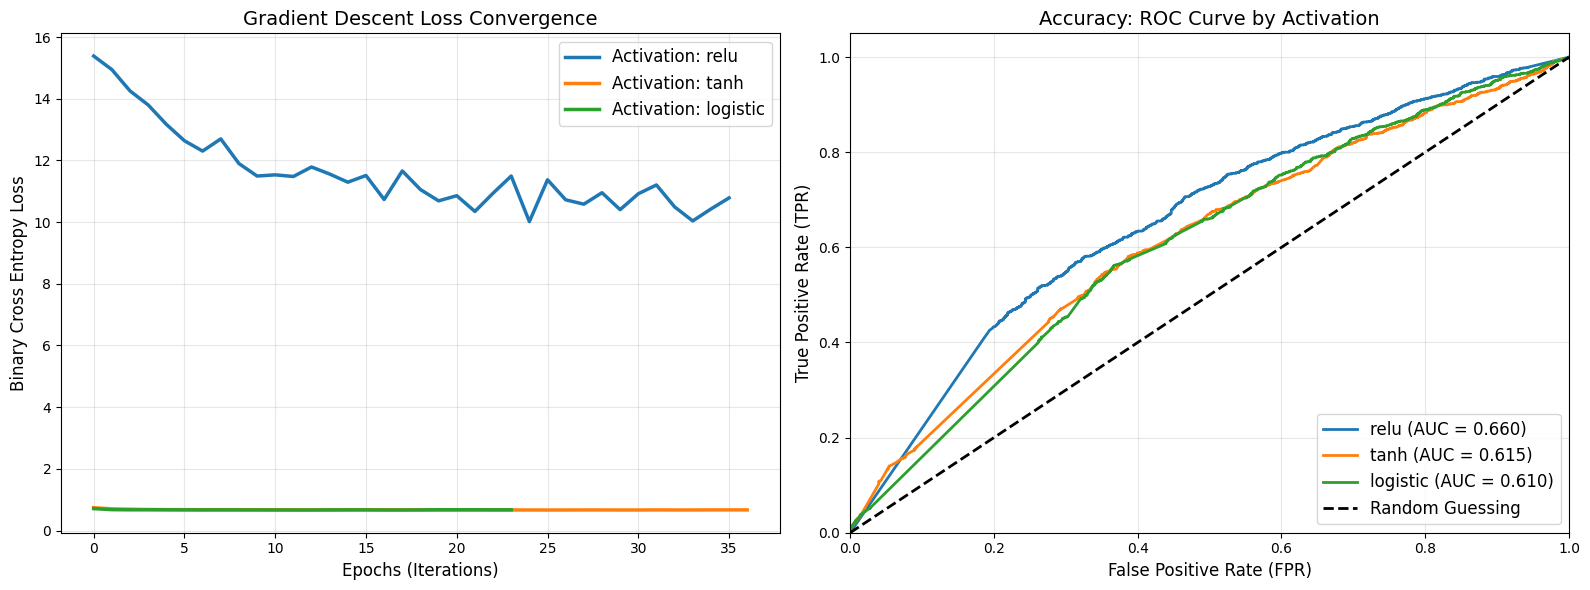

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE

# =========================================================
# 1. Clean BOTH Train and Test Data (The NaN Fix)
# =========================================================
# We must clean the test set as well so the ROC curve can make predictions!
X_train_clean = np.nan_to_num(X_train_optimized, nan=0.0, posinf=0.0, neginf=0.0)
X_test_clean = np.nan_to_num(X_test_optimized, nan=0.0, posinf=0.0, neginf=0.0)

# =========================================================
# 2. Setup SMOTE and Activations
# =========================================================
activations = ['relu', 'tanh', 'logistic'] # 'logistic' is the Sigmoid function
smote = SMOTE(sampling_strategy=1.0, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_clean, y_train)

# Create a figure with two side-by-side graphs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

print("Training ANNs to compare Loss and Accuracy...")

# =========================================================
# 3. Train and Plot Both Curves
# =========================================================
for act in activations:
    print(f"Training with {act}...")

    ann = MLPClassifier(
        hidden_layer_sizes=(50,),
        learning_rate_init=0.0005,
        alpha=0.01,
        activation=act,
        max_iter=5000,
        random_state=42
    )

    # Fit the neural network on the training data
    ann.fit(X_train_smote, y_train_smote)

    # --- GRAPH 1: LOSS CURVE (Training) ---
    axes[0].plot(ann.loss_curve_, label=f"Activation: {act}", linewidth=2.5)

    # --- GRAPH 2: ACCURACY / ROC CURVE (Testing) ---
    # Generate probabilities on the unseen test data to test true accuracy
    y_prob = ann.predict_proba(X_test_clean)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=2, label=f'{act} (AUC = {roc_auc:.3f})')

# =========================================================
# 4. Formatting the Output
# =========================================================
# Format Loss Curve Graph
axes[0].set_title('Gradient Descent Loss Convergence', fontsize=14)
axes[0].set_xlabel('Epochs (Iterations)', fontsize=12)
axes[0].set_ylabel('Binary Cross Entropy Loss', fontsize=12)
axes[0].legend(fontsize=12)
axes[0].grid(alpha=0.3)

# Format Accuracy (ROC) Curve Graph
axes[1].plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random Guessing') # Corrected random guessing line
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (TPR)', fontsize=12)
axes[1].set_title('Accuracy: ROC Curve by Activation', fontsize=14)
axes[1].legend(loc="lower right", fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Individual Loss Curves by Activation Function

To get a clearer view of each activation function's training behavior, especially concerning the `relu` curve, let's plot their loss convergence individually.

Training ANN for relu activation to plot individual loss curve...
Training ANN for tanh activation to plot individual loss curve...
Training ANN for logistic activation to plot individual loss curve...


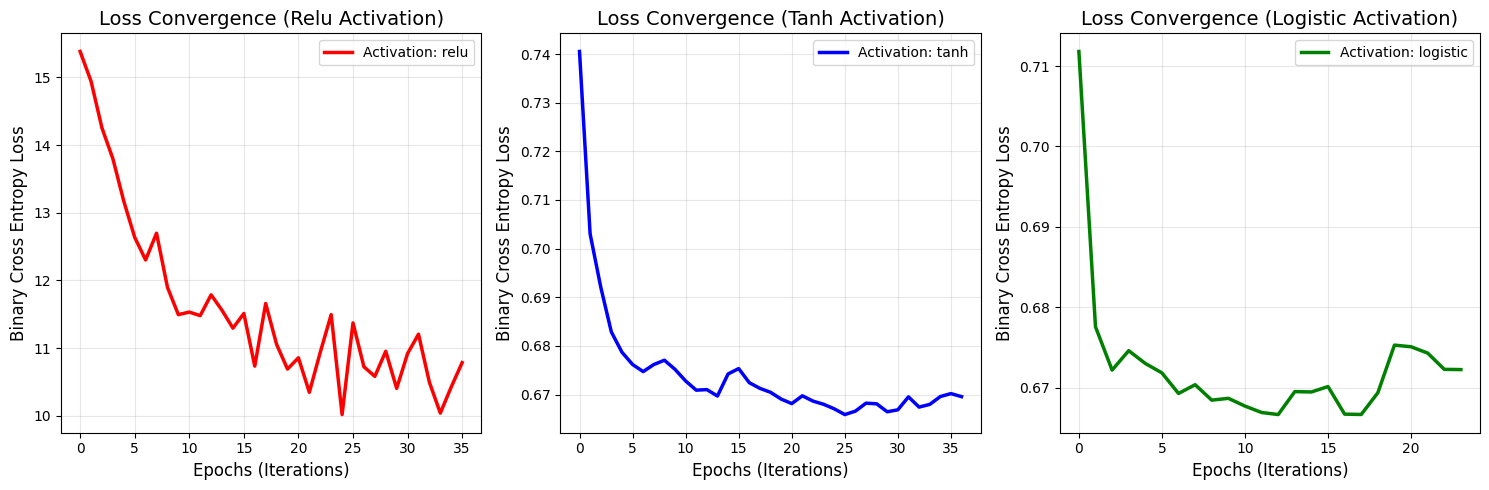

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE

# Re-clean and re-SMOTE the training data for this dedicated plotting cell
# This ensures the cell is self-contained and uses the correct processed data.
X_train_clean = np.nan_to_num(X_train_optimized, nan=0.0, posinf=0.0, neginf=0.0)
smote = SMOTE(sampling_strategy=1.0, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_clean, y_train)

activations = ['relu', 'tanh', 'logistic']

plt.figure(figsize=(15, 5)) # Adjusted figure size for three subplots

for i, act in enumerate(activations):
    print(f"Training ANN for {act} activation to plot individual loss curve...")

    ann = MLPClassifier(
        hidden_layer_sizes=(50,), # Use champion architecture
        learning_rate_init=0.0005, # Use champion architecture
        alpha=0.01, # Use champion architecture
        activation=act,
        max_iter=5000, # Increased max_iter for full convergence visualization
        random_state=42
    )

    ann.fit(X_train_smote, y_train_smote)

    plt.subplot(1, 3, i + 1) # Create 1 row, 3 columns, i+1-th subplot
    plt.plot(ann.loss_curve_, label=f"Activation: {act}", linewidth=2.5, color=['red', 'blue', 'green'][i])
    plt.title(f'Loss Convergence ({act.capitalize()} Activation)', fontsize=14)
    plt.xlabel('Epochs (Iterations)', fontsize=12)
    plt.ylabel('Binary Cross Entropy Loss', fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()


In [30]:
from sklearn.metrics import classification_report

print("\n--- Classification Report for Best ANN Model (Test Set) ---")
print(classification_report(y_test, y_pred_final))


--- Classification Report for Best ANN Model (Test Set) ---
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4667
           1       0.45      0.60      0.52      1326

    accuracy                           0.75      5993
   macro avg       0.66      0.70      0.67      5993
weighted avg       0.78      0.75      0.76      5993



## Model Comparison: Random Forest vs. Artificial Neural Network

Let's compare the performance of the best Random Forest model (chosen from SMOTE vs. Class-weighted approaches) against the champion Artificial Neural Network model, based on their cross-validated F1-Scores.

In [31]:
import pandas as pd
import numpy as np

# 1. Extract Metrics for the Champion Random Forest Model
# The 'comparison_df' already contains the cross-validated metrics.
# The top row (index 0) of comparison_df is the best RF model by F1-Score.
champion_rf_metrics = comparison_df.iloc[0].to_dict()

# 2. Extract Metrics for the Champion ANN Model
# These metrics were stored in best_ann_cv_results after the ANN hyperparameter search.
champion_ann_metrics = {
    "Method": "ANN (Boruta+SMOTENC)",
    "Accuracy": np.mean(best_ann_cv_results['test_accuracy']),
    "Precision": np.mean(best_ann_cv_results['test_precision']),
    "Recall": np.mean(best_ann_cv_results['test_recall']),
    "F1-Score": np.mean(best_ann_cv_results['test_f1'])
}

# 3. Create a Comparison DataFrame
comparison_table_data = [
    champion_rf_metrics,
    champion_ann_metrics
]

model_comparison_df = pd.DataFrame(comparison_table_data)

# Sort by F1-Score in descending order for clear comparison
model_comparison_df = model_comparison_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print("--- Champion Model Comparison (Cross-Validated Metrics) ---")
display(model_comparison_df.round(4))


--- Champion Model Comparison (Cross-Validated Metrics) ---


,Method,Accuracy,Precision,Recall,F1-Score
0,Weight (Class 1 = 3x),0.7971,0.5415,0.5430,0.5421
1,ANN (Boruta+SMOTENC),0.7514,0.4560,0.6291,0.5284


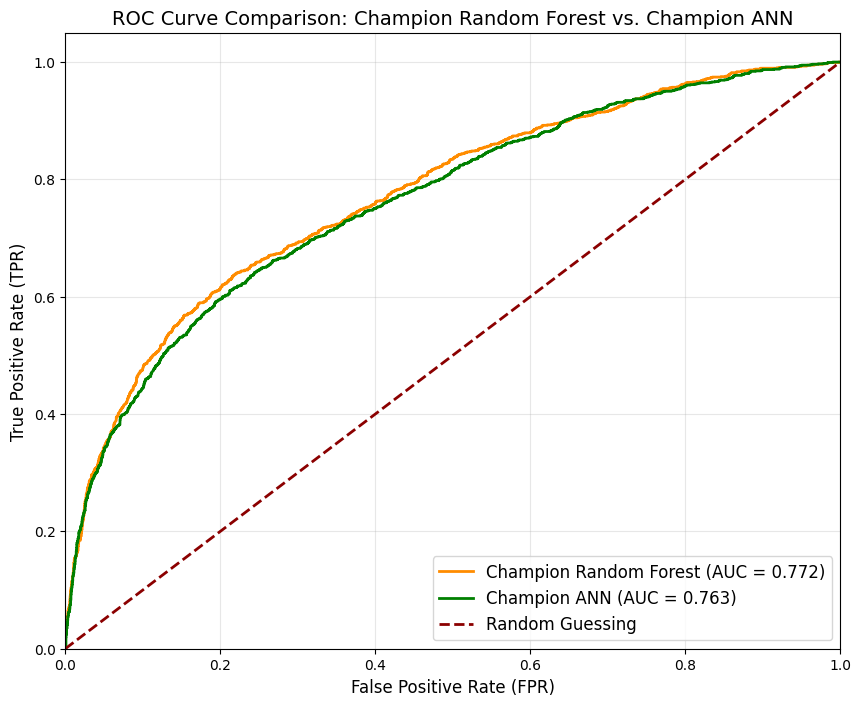

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# Plot Champion Random Forest ROC curve
plt.plot(fpr_weight, tpr_weight, color='darkorange', lw=2, label=f'Champion Random Forest (AUC = {auc_weight:.3f})')

# Plot Champion ANN ROC curve
plt.plot(fpr_ann, tpr_ann, color='green', lw=2, label=f'Champion ANN (AUC = {auc_ann:.3f})')

# Plot the 'Random Guessing' diagonal line
plt.plot([0, 1], [0, 1], color='darkred', lw=2, linestyle='--', label='Random Guessing')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve Comparison: Champion Random Forest vs. Champion ANN', fontsize=14)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

### Model Calibration: Reliability Diagrams and Brier Score

Reliability diagrams (also known as calibration plots) visually assess how well predicted probabilities match true probabilities. If a model predicts a 70% chance of default, we'd expect about 70% of those cases to actually default. The Brier score quantifies this calibration in a single metric, with lower scores indicating better calibration.

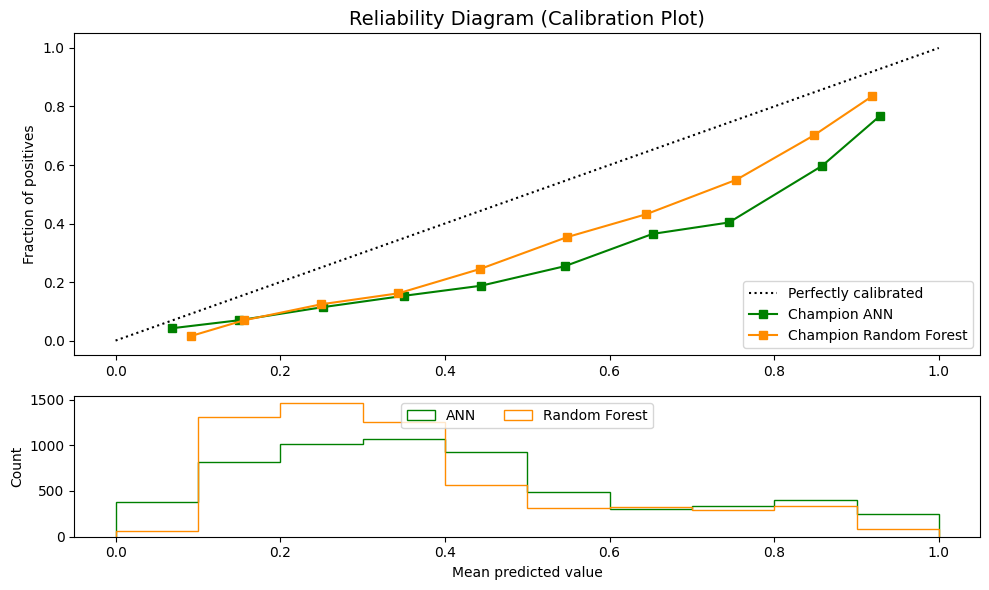


Brier Score for Champion ANN: 0.1837
Brier Score for Champion Random Forest: 0.1604


In [35]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline as SkPipeline

# Instantiate the Champion Random Forest Pipeline (as determined previously)
champion_rf_pipeline = SkPipeline([
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight={0: 1, 1: 3}))
])

# Fit the pipeline on the full optimized training data
# This assumes X_train_optimized and y_train are available from previous cells.
champion_rf_pipeline.fit(X_train_optimized, y_train)


# Get predicted probabilities for the positive class (class 1)
# ANN probabilities
y_prob_ann = champion_pipeline.predict_proba(X_test_optimized)[:, 1]
# RF probabilities
y_prob_rf = champion_rf_pipeline.predict_proba(X_test_optimized)[:, 1]

# --- Plotting Reliability Diagrams ---
plt.figure(figsize=(10, 6))
ax1 = plt.subplot2grid((3, 1), (0, 0), rowspan=2)
ax2 = plt.subplot2grid((3, 1), (2, 0))

ax1.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

# ANN Reliability Curve
fop_ann, mpv_ann = calibration_curve(y_test, y_prob_ann, n_bins=10)
ax1.plot(mpv_ann, fop_ann, "s-", label="Champion ANN", color='green')

# Random Forest Reliability Curve
fop_rf, mpv_rf = calibration_curve(y_test, y_prob_rf, n_bins=10)
ax1.plot(mpv_rf, fop_rf, "s-", label="Champion Random Forest", color='darkorange')

ax1.set_ylabel("Fraction of positives")
ax1.set_ylim([-0.05, 1.05])
ax1.legend(loc="lower right")
ax1.set_title('Reliability Diagram (Calibration Plot)', fontsize=14)

# Plot histograms of the predicted probabilities
ax2.hist(y_prob_ann, range=(0, 1), bins=10, label="ANN", histtype="step", lw=2, color='green')
ax2.hist(y_prob_rf, range=(0, 1), bins=10, label="Random Forest", histtype="step", lw=2, color='darkorange')
ax2.set_xlabel("Mean predicted value")
ax2.set_ylabel("Count")
ax2.legend(loc="upper center", ncol=2)
plt.tight_layout()
plt.show()

# --- Calculating Brier Scores ---
brier_ann = brier_score_loss(y_test, y_prob_ann)
brier_rf = brier_score_loss(y_test, y_prob_rf)

print(f"\nBrier Score for Champion ANN: {brier_ann:.4f}")
print(f"Brier Score for Champion Random Forest: {brier_rf:.4f}")

# A perfectly calibrated model would have a Brier score of 0.
# Lower Brier scores indicate better calibration.

Interpretation: The Brier score quantifies the accuracy of probabilistic predictions. A lower Brier score indicates better calibration, meaning the model's predicted probabilities are closer to the actual observed frequencies. In this case, the Champion Random Forest model has a slightly lower Brier score (0.1604) compared to the Champion ANN (0.1837). This suggests that, on average, the Random Forest model's probability predictions are slightly better calibrated than the ANN's on this test set. This is a valuable insight, especially when the magnitude of the predicted probability matters (e.g., for risk assessment or decision-making based on confidence levels).

## Champion Random Forest: Feature Importance Analysis

Now that we have identified the champion Random Forest model based on its performance on the Boruta-optimized feature set, let's delve into its feature importances. This will help us understand which of the selected features are most critical for the model's predictions.

Fitting the Champion Random Forest on optimized training data...

--- Top 10 Most Important Features for Champion Random Forest ---


,Feature,Importance
0,PAY_0,0.157203
1,Late_Count,0.152579
2,PAY_2,0.088881
3,PAY_3,0.047989
4,Total_Pay,0.040012
5,Utilization_Ratio,0.039548
6,LIMIT_BAL,0.038219
7,PAY_AMT1,0.032833
8,PAY_4,0.032680
9,Total_Bill,0.032553


/tmp/ipykernel_1681/1993240503.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


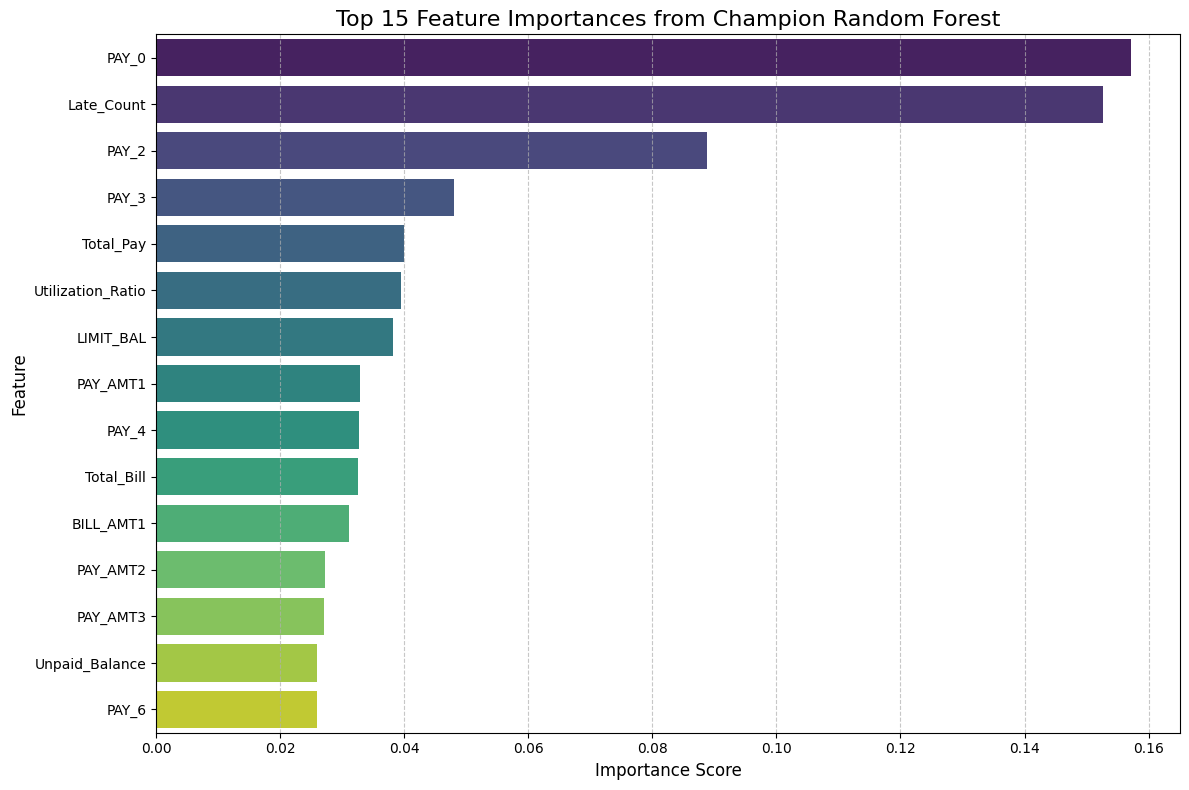

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline as SkPipeline

# 1. Instantiate the Champion Random Forest Pipeline

champion_rf_pipeline = SkPipeline([
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight={0: 1, 1: 3}))
])

# 2. Fit the pipeline on the full optimized training data
print("Fitting the Champion Random Forest on optimized training data...")
champion_rf_pipeline.fit(X_train_optimized, y_train)

# 3. Extract Feature Importances
# The Random Forest classifier is the 'rf' step in the pipeline
feature_importances = champion_rf_pipeline.named_steps['rf'].feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': X_train_optimized.columns,
    'Importance': feature_importances
})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("\n--- Top 10 Most Important Features for Champion Random Forest ---")
display(feature_importance_df.head(10))

# 4. Visualize Feature Importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances from Champion Random Forest', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Fitting the Champion Random Forest on optimized training data...
Evaluating Champion Random Forest on the unseen Holdout Test Set...

--- Classification Report for Champion Random Forest Model (Test Set) ---
              precision    recall  f1-score   support

           0       0.87      0.86      0.87      4667
           1       0.53      0.54      0.53      1326

    accuracy                           0.79      5993
   macro avg       0.70      0.70      0.70      5993
weighted avg       0.79      0.79      0.79      5993



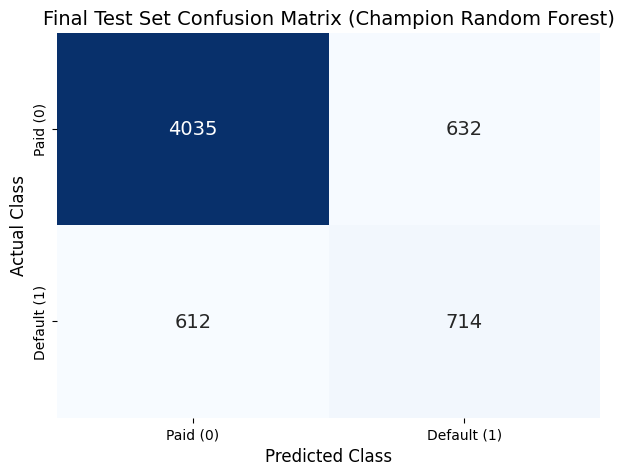

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline as SkPipeline

# Fit the pipeline on the full optimized training data (necessary for predictions)
print("Fitting the Champion Random Forest on optimized training data...")
champion_rf_pipeline.fit(X_train_optimized, y_train)

print("Evaluating Champion Random Forest on the unseen Holdout Test Set...")

# Generate final predictions using the fully optimized test data
y_pred_rf_final = champion_rf_pipeline.predict(X_test_optimized)

# --- Classification Report ---
print("\n--- Classification Report for Champion Random Forest Model (Test Set) ---")
print(classification_report(y_test, y_pred_rf_final))

# --- Confusion Matrix ---
cm_rf_final = confusion_matrix(y_test, y_pred_rf_final)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf_final, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Paid (0)', 'Default (1)'],
            yticklabels=['Paid (0)', 'Default (1)'],
            annot_kws={"size": 14})
plt.title('Final Test Set Confusion Matrix (Champion Random Forest)', fontsize=14)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('Actual Class', fontsize=12)
plt.show()

## Save Champion Model and Preprocessing Steps

Before building the Streamlit dashboard, we need to save the trained champion Random Forest model and the fitted `PowerTransformer` (Yeo-Johnson) instance. This ensures that the dashboard can load and use these exact components for consistent preprocessing and prediction.

In [38]:
import joblib
import os

# Define paths for saving
model_path = 'champion_rf_pipeline.joblib'
transformer_path = 'yeo_johnson_transformer.joblib'

# Save the champion Random Forest pipeline
joblib.dump(champion_rf_pipeline, model_path)
print(f"Champion Random Forest pipeline saved to {model_path}")

# Save the Yeo-Johnson transformer
joblib.dump(yeo_johnson, transformer_path)
print(f"Yeo-Johnson transformer saved to {transformer_path}")

Champion Random Forest pipeline saved to champion_rf_pipeline.joblib
Yeo-Johnson transformer saved to yeo_johnson_transformer.joblib


In [40]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 18.3 MB/s eta 0:00:00
